# Notebook Pruebas

In [8]:
from matplotlib import pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
import trackpy as tp
from skimage import io
import pandas as pd
import pims
import numpy as np
from IPython.display import HTML # For showing the video in Jupyter Notebook


## Archivos

In [21]:
# .tif
PATH_2FPS = "2fps.tif"
PATH_10FPS = "10fps.tif"
PATH_40FPS = "40fps.tif"

STARTING_FRAME = 0
CUT_TOP = 300

frames = pims.open(PATH_40FPS)



## Preprocesado

frames shape: (3248, 1024, 504)


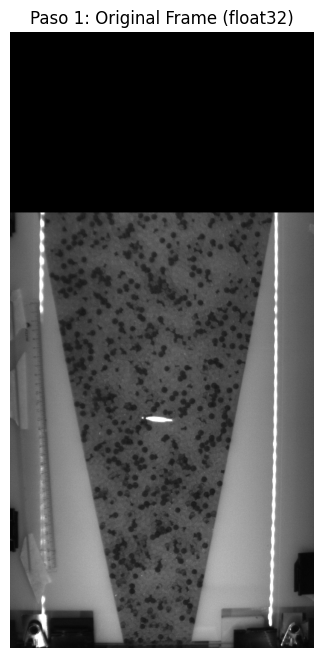

In [22]:
# Convertimos los datos a flotante para no perder precisión en la matemática
frames = np.array(frames, dtype=np.float32)
frames = frames[STARTING_FRAME:]
frames[:, :CUT_TOP, :] = 0  

print("frames shape:", frames.shape)

# Visualizamos un frame de ejemplo (el índice 1)
plt.figure(figsize=(6, 8))
plt.imshow(frames[1], cmap="gray")
plt.title("Paso 1: Original Frame (float32)")
plt.axis("off")
plt.show()

Como nuestro sistema es un flujo denso, usamos el máximo temporal (`np.max`) para encontrar el estado donde cada píxel recibió la mayor cantidad de luz (el silo vacío).

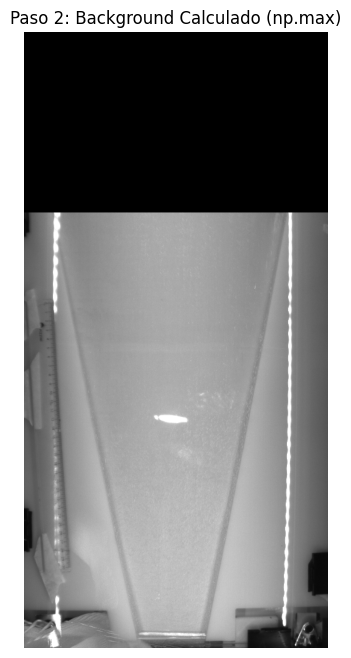

In [ ]:
# Buscamos el estado más iluminado de cada píxel en el tiempo
background = np.max(frames, axis=0)
plt.figure(figsize=(6, 8))
plt.imshow(background, cmap="gray")
plt.title("Paso 2: Background Calculado (np.max)")
plt.axis("off")
plt.show()


Restamos el frame actual al fondo. Como las bolitas trazadoras son oscuras, esta operación matemática las invierte y las convierte en puntos de alta intensidad (positivos).

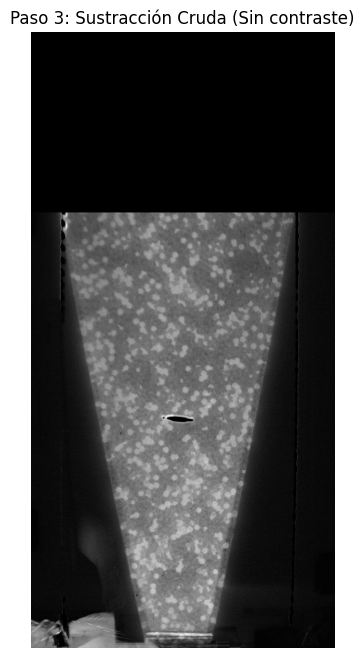

In [24]:
# Fondo claro - Bolita oscura = Bolita brillante
# np.subtract con out= evita el array temporal que crearía background - frames
np.subtract(background, frames, out=frames)

plt.figure(figsize=(6, 8))
plt.imshow(frames[1], cmap="gray")
plt.title("Paso 3: Sustracción Cruda (Sin contraste)")
plt.axis("off")
plt.show()

Para maximizar la precisión sub-píxel de Trackpy, estiramos el rango dinámico de la imagen para que las trazadoras sean lo más brillantes posible sin llegar a saturarse y perder su forma gaussiana.

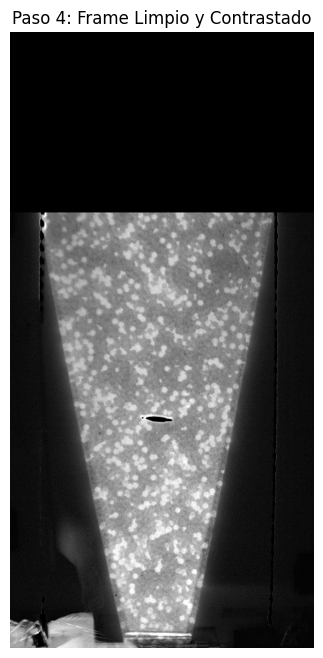

In [25]:
# Encontramos los límites reales de la imagen, ignorando picos extremos de ruido
v_min = np.min(frames)
v_max = np.percentile(frames, 99.9)

# Estiramiento lineal en sitio: modifica frames directamente para no duplicar memoria
frames -= v_min
frames /= (v_max - v_min)
frames *= 240.0
np.clip(frames, 0, 255, out=frames)

# Conversión a uint8 (1 byte/px) y liberación del float32 (4 bytes/px)
frames_clean = frames.astype(np.uint8)
del frames

plt.figure(figsize=(6, 8))
plt.imshow(frames_clean[1], cmap="gray")
plt.title("Paso 4: Frame Limpio y Contrastado")
plt.axis("off")
plt.show()

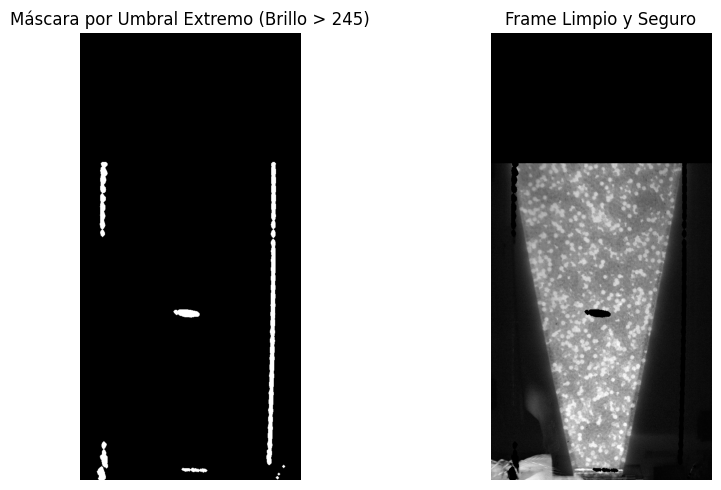

In [26]:
from scipy.ndimage import binary_dilation

# 1. Encontramos brillos mayores al umbral extremo (reflejos puros)
led_threshold = 245
led_mask = background > led_threshold
del background  # ya no se usa después de aquí

# ======================================================

# 2. Engordamos un poquito esa máscara para cubrir el resplandor
dilated_led_mask = binary_dilation(led_mask, iterations=3)

# 3. Aplicamos la máscara en sitio ([:, mask] itera sobre todos los frames)
frames_clean[:, dilated_led_mask] = 0
frames_masked = frames_clean
del frames_clean

# Visualizamos los resultados
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(dilated_led_mask, cmap='gray')
plt.title("Máscara por Umbral Extremo (Brillo > 245)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(frames_masked[1], cmap='gray')
plt.title("Frame Limpio y Seguro")
plt.axis("off")

plt.tight_layout()
plt.show()

## Tracking / trackpy

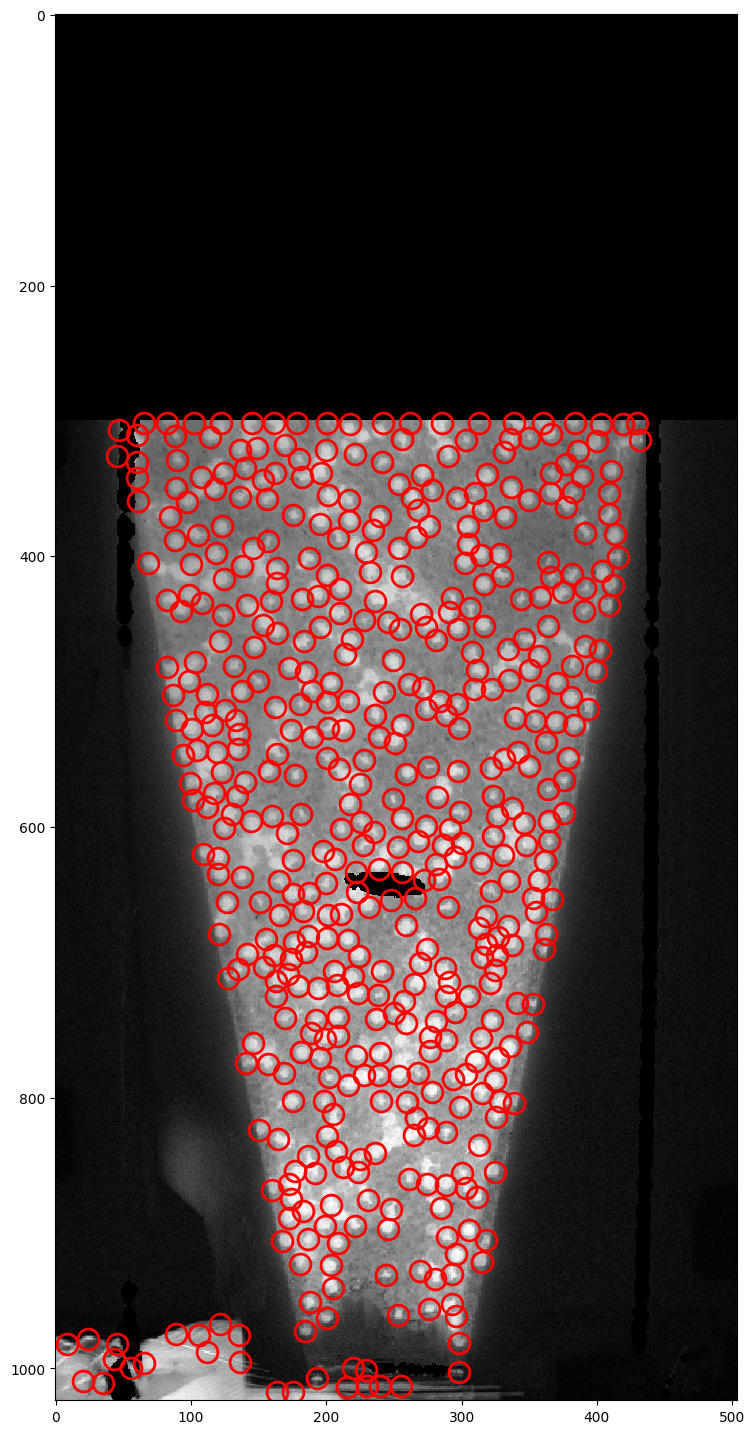

<Axes: >

In [37]:
# 1. Parámetros de prueba (Nuevos)
# Bajamos diámetro a 7 (para que calce mejor) 
# Bajamos minmass de 500 a 100 o 200 (para atrapar las del centro)
DIAMETER = 9 
MINMASS = 350

# 2. Corremos locate en un solo frame (rápido para iterar)
test_features = tp.locate(frames_masked[500], DIAMETER, minmass=MINMASS)

# 3. Visualizamos con zoom
plt.figure(figsize=(18, 18))
tp.annotate(test_features, frames_masked[500])


1152170 features encontrados en toda la secuencia


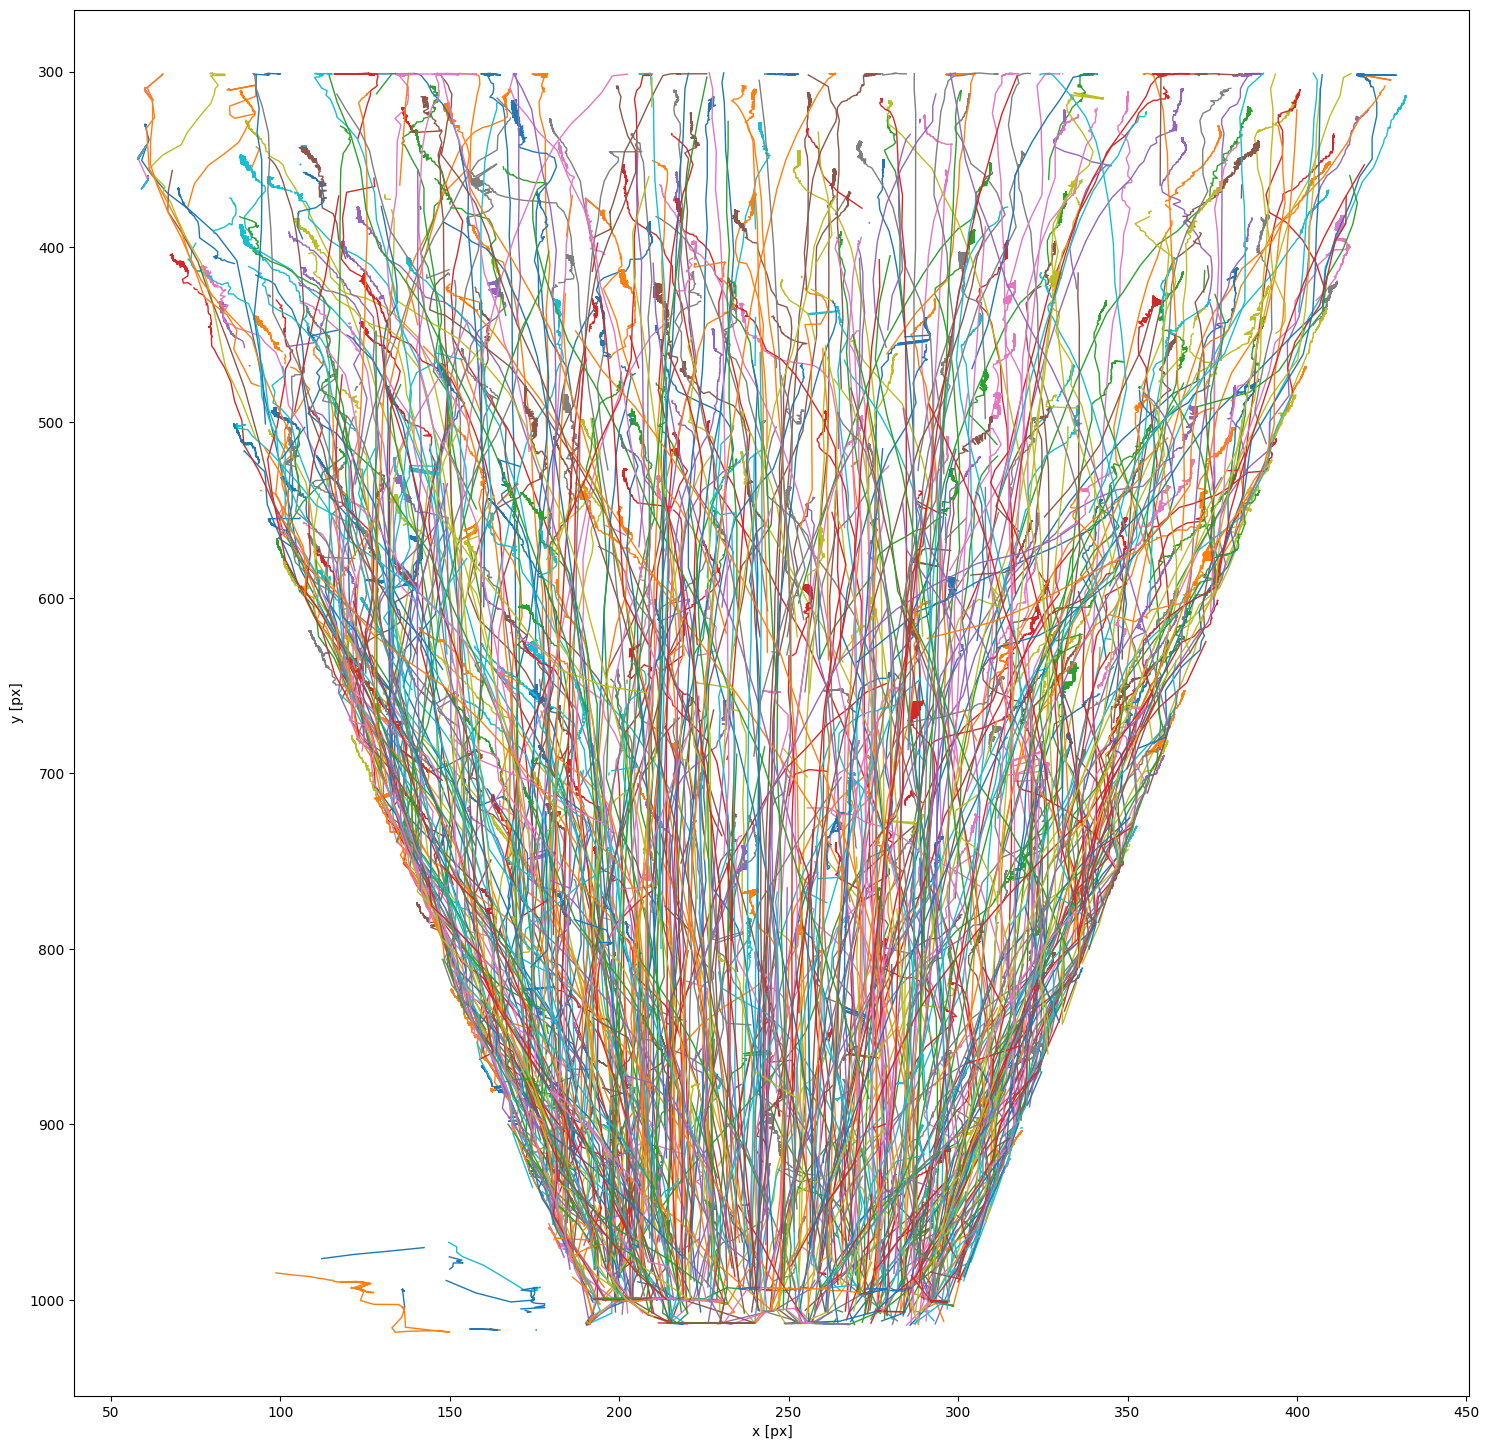

<Axes: xlabel='x [px]', ylabel='y [px]'>

In [38]:
tp.quiet()

features = tp.batch(frames_masked, diameter=DIAMETER, minmass=MINMASS) 
print(len(features), "features encontrados en toda la secuencia")

predictor = tp.predict.NearestVelocityPredict()
t = predictor.link_df(features, search_range=10, memory=4) 


# t = tp.link(features, search_range=10, memory=4) # Ajustados link/memory para flujo denso
t = tp.filter_stubs(t, 10) # Trayectorias de al menos 10 frames

MINIMUM_Y = 30

particles_delta = t.groupby("particle").aggregate({"y": ["max", "min"]})
particles_with_enough_y_movement = particles_delta[particles_delta[("y", "max")] - particles_delta[("y", "min")] > MINIMUM_Y]
t = t[t.particle.isin(particles_with_enough_y_movement.index)]

# Plotting on the subtracted frame for context
plt.figure(figsize=(18, 18))
tp.plot_traj(t)

## Campo de velocidades 

### Calculo 

In [39]:
t= t.reset_index(drop=True).copy()

Ordenamos por particula y por tiempo (frame) para garantizar la diferencia entre particulas.  

In [40]:
t.sort_values(['particle', 'frame'], inplace=True)

Luego utilizamos el Filtro de `Savtizky-Golay` en el que en lugar de dos puntos, tomamos una ventana de tiempo y ajustamos un polinomio `p(t) = at^2 + bt + c`. La velocidad es la derivada analitica de ese polinomio. 

In [41]:
from scipy.signal import savgol_filter

# window_length: Cantidad de frames a mirar para suavizar 
# polyorder: Grado del polinomio a ajustar 
sg_window = 7  
sg_poly = 2    

def calculate_smooth_velocity(group):
    if len(group) > sg_window:
        # deriv=1 calcula directamente la primera derivada (velocidad en px/frame)
        group['vx'] = savgol_filter(group['x'], window_length=sg_window, polyorder=sg_poly, deriv=1)
        group['vy'] = savgol_filter(group['y'], window_length=sg_window, polyorder=sg_poly, deriv=1)
    else:
        group['vx'] = np.nan
        group['vy'] = np.nan
    return group

t = t.groupby('particle', group_keys=False).apply(calculate_smooth_velocity)
t.dropna(subset=['vx', 'vy'], inplace=True)

Lo dividimos en una grilla 

In [42]:
grid_size = 25 # píxeles
x_bins = np.arange(t.x.min(), t.x.max() + grid_size, grid_size)
y_bins = np.arange(t.y.min(), t.y.max() + grid_size, grid_size)
x_bins

array([ 57.97955975,  82.97955975, 107.97955975, 132.97955975,
       157.97955975, 182.97955975, 207.97955975, 232.97955975,
       257.97955975, 282.97955975, 307.97955975, 332.97955975,
       357.97955975, 382.97955975, 407.97955975, 432.97955975])

In [43]:
y_bins

array([ 300.69152542,  325.69152542,  350.69152542,  375.69152542,
        400.69152542,  425.69152542,  450.69152542,  475.69152542,
        500.69152542,  525.69152542,  550.69152542,  575.69152542,
        600.69152542,  625.69152542,  650.69152542,  675.69152542,
        700.69152542,  725.69152542,  750.69152542,  775.69152542,
        800.69152542,  825.69152542,  850.69152542,  875.69152542,
        900.69152542,  925.69152542,  950.69152542,  975.69152542,
       1000.69152542, 1025.69152542])

Asignamos por bins: 

In [44]:
t['x_bin'] = pd.cut(t['x'], bins=x_bins, labels=False)
t['y_bin'] = pd.cut(t['y'], bins=y_bins, labels=False)

nx_bins = len(x_bins) - 1
ny_bins = len(y_bins) - 1

Calculamos las matrices por X e Y: 

In [45]:
Px = t.pivot_table(
    index="y_bin", columns="x_bin", values="vx", aggfunc="mean"
)
Px = Px.reindex(index=range(ny_bins), columns=range(nx_bins))
Py = t.pivot_table(
    index="y_bin", columns="x_bin", values="vy", aggfunc="mean"
)
Py = Py.reindex(index=range(ny_bins), columns=range(nx_bins))


### Animación de campo: 

In [46]:
# Animations frames : 
grid_data = t.groupby(['frame', 'y_bin', 'x_bin'])[['vx', 'vy']].mean()

def get_dense_grid(frame_idx, value_col):
    try:
        data = grid_data.loc[frame_idx][value_col].unstack(fill_value=0)
        return data.reindex(index=range(ny_bins), columns=range(nx_bins), fill_value=0).values
    except KeyError:
        return np.zeros((ny_bins, nx_bins))
    
frames_list = sorted(t['frame'].unique())
num_frames = len(frames_list)

all_vx = np.array([get_dense_grid(f, 'vx') for f in frames_list])
all_vy = np.array([get_dense_grid(f, 'vy') for f in frames_list])
all_speed = np.sqrt(all_vx**2 + all_vy**2)

In [ ]:
plt.rcParams['animation.embed_limit'] = 200
fig, ax = plt.subplots(figsize=(10, 8))
X, Y = np.meshgrid(np.arange(nx_bins), np.arange(ny_bins))

Q = ax.quiver(X, Y, all_vx[0], -all_vy[0], all_speed[0], cmap="plasma", scale=40, width=0.005)
ax.invert_yaxis()
title = ax.set_title(f"Frame {frames_list[0]}")

def update(i):
    vx, vy, speed = all_vx[i], all_vy[i], all_speed[i]
    Q.set_UVC(vx, -vy, speed)
    title.set_text(f"Frame {frames_list[i]}")
    return Q, title

ani = FuncAnimation(fig, update, frames=num_frames, interval=50, blit=True)
ani.save('my_animation.mp4', writer='ffmpeg', fps=20)
plt.close()
HTML(ani.to_jshtml())